# Assessment 2.2 - Evaluating the performance of RNN, LSTM, and GRU on time-series predictions on a Bike Rental Dataset.

Student Name = Izzaz Iskandar bin Ismail

Student ID = 08052342

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from keras.src.losses import mean_absolute_error
from sklearn.metrics import r2_score
from tensorflow.python.ops.losses.losses_impl import mean_squared_error

warnings.filterwarnings('ignore')

dataset_hour : pd.DataFrame = pd.read_csv("DATA/hour.csv")
dataset_day : pd.DataFrame = pd.read_csv("DATA/day.csv")

## Bike Rentals by Day

### Data Preprocessing

#### Outlier Management


In [2]:
# Inspect the hour dataset
dataset_day.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 91.5 KB


In [3]:
dataset_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
dataset_day.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Comments:
- The dataset has been well prepared with a lot of the columns being scaled already.

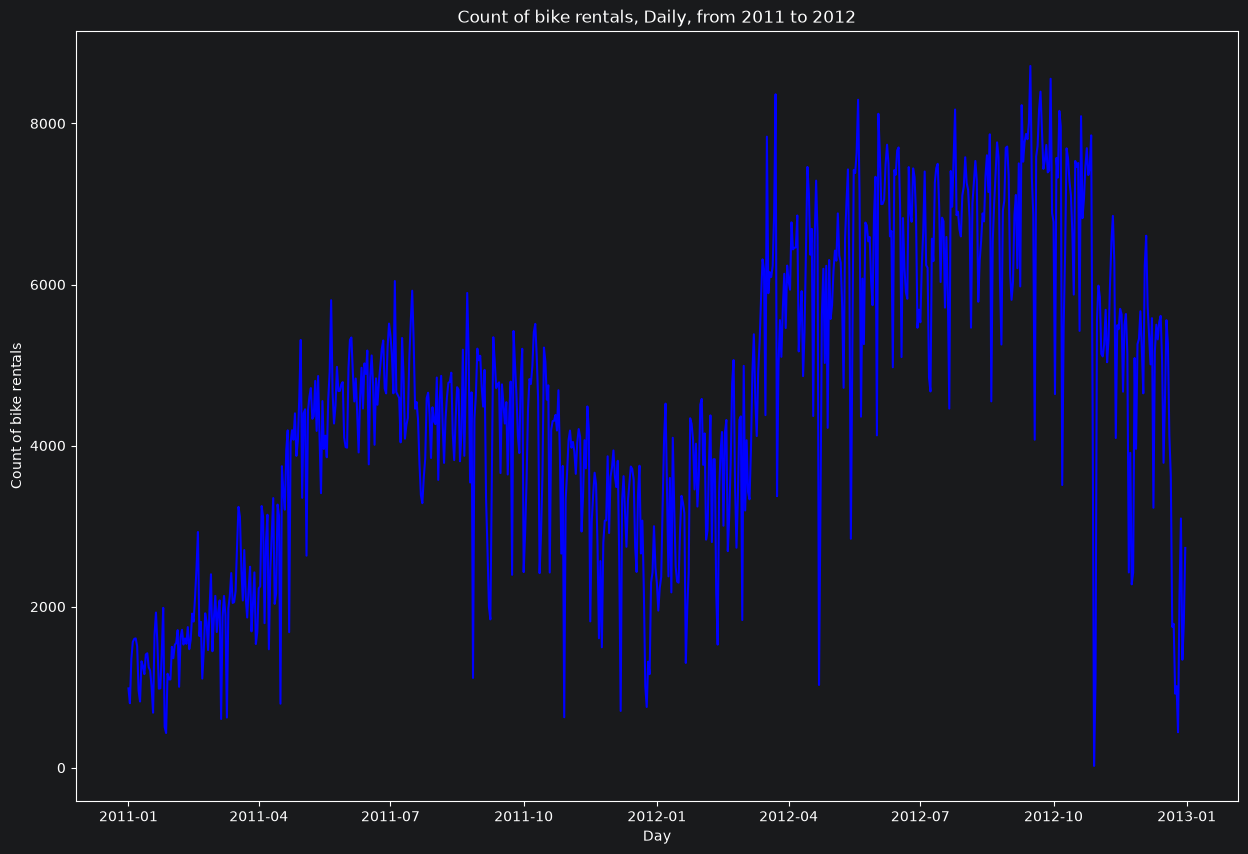

In [5]:
dataset_day["dteday"] = pd.to_datetime(dataset_day["dteday"])

plt.figure(figsize=(15,10))
plt.plot(dataset_day["dteday"], dataset_day["cnt"], color="blue")
plt.xlabel("Day")
plt.ylabel("Count of bike rentals")
plt.title("Count of bike rentals, Daily, from 2011 to 2012")
plt.show()

While there are some daily and yearly seasonality features present, there are days which there are massive outliers.

We will be imputing these outliers with the median value of the bike rental counts for that date's specific month.

In [6]:
# Get the month for grouping
dataset_day["month"] = dataset_day["dteday"].dt.to_period("M")

# Find the median value for each of those months
median_values : pd.Series = (
    dataset_day
    .groupby("month")
    .cnt
    .median()
)

# Find outlier value bounds for those months using Interquartile Ranges
percentile_25th : pd.Series = (
    dataset_day
    .groupby("month")
    .cnt
    .quantile(0.25)
)

percentile_75th : pd.Series = (
    dataset_day
    .groupby("month")
    .cnt
    .quantile(0.75)
)

# Find interquartile Ranges to get lower_bounds and upper_bounds
iqr : pd.Series = percentile_75th - percentile_25th
lower_bounds : pd.Series = percentile_25th - 1.5 * iqr
upper_bounds : pd.Series = percentile_75th + 1.5 * iqr

# Identify outliers
dataset_day["monthly_lower_bound"] = dataset_day["month"].map(lower_bounds)
dataset_day["monthly_upper_bound"] = dataset_day["month"].map(upper_bounds)
dataset_day["monthly_median"] = dataset_day["month"].map(median_values)

is_outlier = ((dataset_day["cnt"] < dataset_day["monthly_lower_bound"]) | (dataset_day["cnt"] > dataset_day["monthly_upper_bound"]))


In [7]:
# Impute
dataset_day["cnt"] = np.where(is_outlier, dataset_day["monthly_median"], dataset_day["cnt"])
dataset_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,month,monthly_lower_bound,monthly_upper_bound,monthly_median
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985.0,2011-01,205.5,2285.5,1248.0
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801.0,2011-01,205.5,2285.5,1248.0
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349.0,2011-01,205.5,2285.5,1248.0
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562.0,2011-01,205.5,2285.5,1248.0
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600.0,2011-01,205.5,2285.5,1248.0


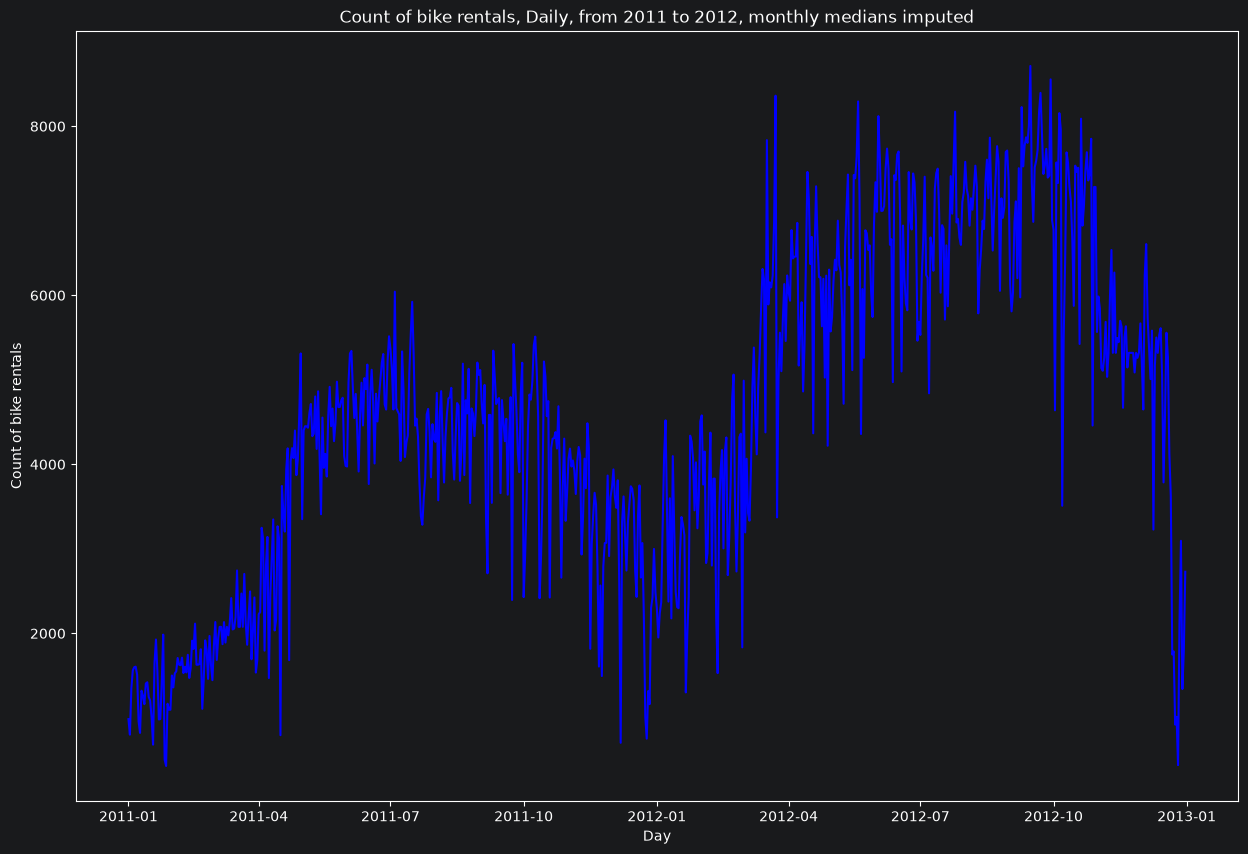

In [8]:
# Check the daily plot again
plt.figure(figsize=(15,10))
plt.plot(dataset_day["dteday"], dataset_day["cnt"], color="blue")
plt.xlabel("Day")
plt.ylabel("Count of bike rentals")
plt.title("Count of bike rentals, Daily, from 2011 to 2012, monthly medians imputed")
plt.show()

#### Encoding

Encoding on categorical values (non-temporal)

In [9]:
one_hot = pd.get_dummies(dataset_day["weathersit"], prefix="weathersit")
dataset_day = dataset_day.join(one_hot)

In [10]:
one_hot = pd.get_dummies(dataset_day["season"], prefix="season")
dataset_day = dataset_day.join(one_hot)

Encoding on cyclical values (temporal values)

In [11]:
# For Weekday (0-6)
dataset_day["weekday_sin"] = np.sin(2 * np.pi * dataset_day["weekday"] / 7)
dataset_day["weekday_cos"] = np.cos(2 * np.pi * dataset_day["weekday"] / 7)

# For Month (1-12) , subtract by 1 so its 0-11
dataset_day["mnth_sin"] = np.sin(2 * np.pi * (dataset_day["mnth"] - 1) / 12)
dataset_day["mnth_cos"] = np.cos(2 * np.pi * (dataset_day["mnth"] - 1) / 12)

#### Scaling

Scaling on "cnt" to avoid gradient explosion

In [12]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler = MinMaxScaler(feature_range=(0, 1))
dataset_day["cntscl"] = scaler.fit_transform(dataset_day[["cnt"]])

### Data Splitting

We will take 70% of total dataset size to train, 15% as validation, and 15% as test.

In [13]:
total_days: int = len(dataset_day)
training_days : int = round(total_days * 0.7)
validation_days : int = (round((total_days - training_days) / 2))
testing_days : int = total_days - training_days - validation_days

print(f"Total dataset days: {total_days}\nTraining days: {training_days}\nValidation days: {validation_days}\nTesting days: {testing_days}")

Total dataset days: 731
Training days: 512
Validation days: 110
Testing days: 109


In [14]:
df_train : pd.DataFrame = dataset_day[:training_days]
df_validation : pd.DataFrame = dataset_day[training_days : training_days + validation_days]
df_test : pd.DataFrame = dataset_day[training_days + validation_days:]

### Model Training

To guarantee fairness in comparison, every model will be with consistent architecture.

In [15]:
# Feature Selection
feature_cols : list[str] = [
    # environmental features
    "temp",
    "atemp",
    "hum",
    "windspeed",
    # Seasonal features
    "holiday",
    "workingday",
    "yr",
    "season_1",
    "season_2",
    "season_3",
    "season_4",
    "weathersit_1",
    "weathersit_2",
    "weathersit_3",
    # Cyclical features
    "weekday_sin",
    "weekday_cos",
    "mnth_sin",
    "mnth_cos",
    "cntscl"
]

In [16]:
# Build a function to dynamically create the lookback windows
def create_sequences(
        df: pd.DataFrame,
        features: list[str],
        target_col: str = "cntscl",
        look_back: int = 7
) -> tuple[np.ndarray, np.ndarray]:
    """
    Function to create the lookback windows based on the data
    :param df: Dataframe
    :param features: list of features
    :param target_col: target column to be predicted
    :param look_back: chosen lookback window, in days
    :return: Returns a tuple of two arrays, X = 3D features matrix of shape (samples, time_steps, features) and Y = 1D target matrix of shape (samples,)
    """
    x_list: list[np.ndarray] = []
    y_list: list[float] = []

    feature_data: np.ndarray = df[features].values
    target_data: np.ndarray = df[target_col].values

    for i in range(len(df) - look_back):
        x_list.append(feature_data[i:i + look_back])
        y_list.append(target_data[i + look_back])

    return np.array(x_list, dtype=np.float64), np.array(y_list, dtype=np.float64)

In [17]:
# Generate sequences for Train, Validation, and Test sets
look_back: int = 7
X_train, y_train = create_sequences(df_train, feature_cols, look_back=look_back)
X_val, y_validation = create_sequences(df_validation, feature_cols, look_back=look_back)
X_test, y_test = create_sequences(df_test, feature_cols, look_back=look_back)

print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Validation shapes: X={X_val.shape}, y={y_validation.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")

Train shapes: X=(505, 7, 19), y=(505,)
Validation shapes: X=(103, 7, 19), y=(103,)
Test shapes: X=(102, 7, 19), y=(102,)


#### SimpleRNN Model

In [18]:
from tensorflow.keras import Sequential, layers

input_shape: tuple[int,int] = (int(X_train.shape[1]), int(X_train.shape[2]))
rnn_model: Sequential = Sequential([
    layers.InputLayer(input_shape=input_shape),
    layers.SimpleRNN(64, activation="tanh", return_sequences=True, dropout=0.2),
    layers.SimpleRNN(32, activation="tanh", return_sequences=False, dropout=0.2),
    layers.Dense(1)
], name="rnn_model")

In [19]:
# Compile model
from tensorflow.keras.optimizers import Adam
rnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

In [20]:
rnn_model.summary(print_fn=print)

Model: "rnn_model"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 7, 64)          │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 8,513 (33.25 KB)
 Trainable params: 8,513 (33.25 KB)
 Non-trainable params: 0 (0.00 B)



In [21]:
# Train on the training set
# We will use some callbacks as defined in tensorflow documentation for early stopping at maximum loss => https://www.tensorflow.org/guide/keras/writing_your_own_callbacks?hl=en#examples_of_keras_callback_applications

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback, History
callbacks: list[Callback] = [
    EarlyStopping(monitor="val_loss", patience=15, mode="auto"), # prevent overfit, set 15 epochs
    ReduceLROnPlateau(monitor="val_loss", patience=5, mode="auto"), # shrink learning rate, set 5 epochs
]

history_rnn : History = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_validation),
    epochs=100,
    callbacks=callbacks,
    batch_size=16,
    verbose=1
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2130 - mae: 0.3566 - val_loss: 0.1246 - val_mae: 0.3124 - learning_rate: 0.0010
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0844 - mae: 0.2269 - val_loss: 0.0525 - val_mae: 0.2047 - learning_rate: 0.0010
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0549 - mae: 0.1855 - val_loss: 0.0605 - val_mae: 0.2249 - learning_rate: 0.0010
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0409 - mae: 0.1607 - val_loss: 0.0466 - val_mae: 0.1938 - learning_rate: 0.0010
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0352 - mae: 0.1489 - val_loss: 0.0264 - val_mae: 0.1392 - learning_rate: 0.0010
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0307 - mae: 0.1382 - val_loss: 0.0376 - val_mae: 0.1699 - learning_rate: 0.0010
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0337 - mae: 0.1408 - val_loss: 0.0516 - val_mae: 0.2046 - learning_rate: 0.0010
Epoch 8/100
3

RNN model trained successfully, will train the other models now

#### LSTM Model

In [22]:
lstm_model: Sequential = Sequential([
    layers.InputLayer(input_shape=input_shape),
    layers.LSTM(64, activation="tanh", return_sequences=True, dropout=0.2),
    layers.LSTM(32, activation="tanh", return_sequences=False, dropout=0.2),
    layers.Dense(1)
], name="lstm_model")

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

# Training on the same callbacks
history_lstm: History = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_validation),
    epochs=100,
    callbacks=callbacks,
    batch_size=16,
    verbose=1
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0351 - mae: 0.1459 - val_loss: 0.0174 - val_mae: 0.1147 - learning_rate: 0.0010
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0168 - mae: 0.1003 - val_loss: 0.0212 - val_mae: 0.1292 - learning_rate: 0.0010
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0166 - mae: 0.0955 - val_loss: 0.0262 - val_mae: 0.1448 - learning_rate: 0.0010
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0168 - mae: 0.1009 - val_loss: 0.0500 - val_mae: 0.2063 - learning_rate: 0.0010
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0165 - mae: 0.0994 - val_loss: 0.0198 - val_mae: 0.1219 - learning_rate: 0.0010
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0153 - mae: 0.0926 - val_loss: 0.0310 - val_mae: 0.1585 - learning_rate: 0.0010
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0145 - mae: 0.0884 - val_loss: 0.0266 - val_mae: 0.1453 - learning_rate: 1.0000e-04
Epoch 8/1

In [23]:
gru_model: Sequential = Sequential([
    layers.InputLayer(input_shape=input_shape),
    layers.GRU(64, activation="tanh", return_sequences=True, dropout=0.2),
    layers.GRU(32, activation="tanh", return_sequences=False, dropout=0.2),
    layers.Dense(1)
], name="lstm_model")

gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

# Training on the same callbacks
history_gru: History = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_validation),
    epochs=100,
    callbacks=callbacks,
    batch_size=16,
    verbose=1
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0287 - mae: 0.1321 - val_loss: 0.0293 - val_mae: 0.1483 - learning_rate: 0.0010
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0236 - mae: 0.1183 - val_loss: 0.0118 - val_mae: 0.0908 - learning_rate: 0.0010
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0183 - mae: 0.1046 - val_loss: 0.0231 - val_mae: 0.1325 - learning_rate: 0.0010
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0162 - mae: 0.0991 - val_loss: 0.0191 - val_mae: 0.1205 - learning_rate: 0.0010
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0194 - mae: 0.1061 - val_loss: 0.0085 - val_mae: 0.0774 - learning_rate: 0.0010
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0174 - mae: 0.0995 - val_loss: 0.0168 - val_mae: 0.1120 - learning_rate: 0.0010
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0162 - mae: 0.0976 - val_loss: 0.0149 - val_mae: 0.1053 - learning_rate: 0.0010
Epoch 8/100
3

### Plot of training and test loss functions


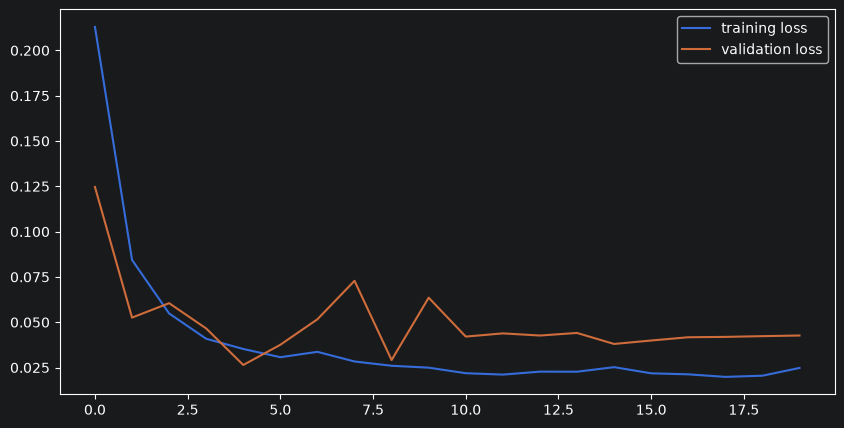

In [24]:
losses = history_rnn.history["loss"]
val_losses = history_rnn.history["val_loss"]
plt.figure(figsize=(10, 5))
plt.plot(losses, label="training loss")
plt.plot(val_losses, label="validation loss")
plt.legend()
plt.show()

### Predicting on the test data

In [25]:
# Create function to evaluate the models
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def evaluate_model(
        model: Sequential,
        x_data: np.ndarray,
        y_true_scaled: np.ndarray,
        scaler: MinMaxScaler,
) -> tuple[np.ndarray, np.ndarray, dict[str, float]]:
    """
    Predicts using the trained model, unscales the predictions, then computes metrics
    :param model: the chosen model
    :param x_data: the array of features
    :param y_true_scaled: true value of target var, scaled
    :param scaler: what scaler was used
    :return: A typle of actual rental counts array, predicted rental counts array, and metrics (dict)
    """
    y_pred_scaled : np.ndarray = model.predict(x_data)

    y_pred_unscaled : np.ndarray = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))
    y_true_unscaled : np.ndarray = scaler.inverse_transform(y_true_scaled.reshape(-1, 1))

    mse: float = mean_squared_error(y_true_unscaled, y_pred_unscaled)
    rmse: float = np.sqrt(mse)
    mae: float = mean_absolute_error(y_true_unscaled, y_pred_unscaled)
    r2: float = r2_score(y_true_unscaled, y_pred_unscaled)

    metrics: dict[str, float] = {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

    return y_true_unscaled.flatten(), y_pred_unscaled.flatten(), metrics




In [26]:
# Evaluate SimpleRNN
y_true, y_pred_rnn, rnn_metrics = evaluate_model(rnn_model, X_test, y_test, scaler)

print("=== SimpleRNN Evaluation Metrics ===")
print(f"Mean Squared Error (MSE):\t\t\t{rnn_metrics["MSE"]:.2f}")
print(f"Root Mean Squared Error (RMSE):\t\t{rnn_metrics['RMSE']:.2f}")
print(f"MAE:\t\t\t\t\t\t\t\t{rnn_metrics['MAE']:.2f}")
print(f"R2:\t\t\t\t\t\t\t\t\t{rnn_metrics['R2']:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
=== SimpleRNN Evaluation Metrics ===
Mean Squared Error (MSE):			3208908.15
Root Mean Squared Error (RMSE):		1791.34
MAE:								1543.61
R2:									-0.03


In [27]:
# Evaluate LSTM
y_true, y_pred_lstm, lstm_metrics = evaluate_model(lstm_model, X_test, y_test, scaler)

print("=== LSTM Evaluation Metrics ===")
print(f"Mean Squared Error (MSE):\t\t\t{lstm_metrics["MSE"]:.2f}")
print(f"Root Mean Squared Error (RMSE):\t\t{lstm_metrics['RMSE']:.2f}")
print(f"MAE:\t\t\t\t\t\t\t\t{lstm_metrics['MAE']:.2f}")
print(f"R2:\t\t\t\t\t\t\t\t\t{lstm_metrics['R2']:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
=== LSTM Evaluation Metrics ===
Mean Squared Error (MSE):			2495609.04
Root Mean Squared Error (RMSE):		1579.75
MAE:								1325.33
R2:									0.20


In [28]:
# Evaluate GRU

y_true, y_pred_gru, gru_metrics = evaluate_model(gru_model, X_test, y_test, scaler)

print("=== GRU Evaluation Metrics ===")
print(f"Mean Squared Error (MSE):\t\t\t{gru_metrics["MSE"]:.2f}")
print(f"Root Mean Squared Error (RMSE):\t\t{gru_metrics['RMSE']:.2f}")
print(f"MAE:\t\t\t\t\t\t\t\t{gru_metrics['MAE']:.2f}")
print(f"R2:\t\t\t\t\t\t\t\t\t{gru_metrics['R2']:.2f}")

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x121597e20> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
=== GRU Evaluation Metrics ===
Mean Squared Error (MSE):			2156816.41
Root Mean Squared Error (RMSE):		1468.61
MAE:								1225.64
R2:									0.31


## Model Comparison and Visualizations

In this section, we compare the prediction performance of the **SimpleRNN**, **LSTM**, and **GRU** models visually on the test set. All metrics and predictions are in original, unscaled unit values (bike rental counts).

In [29]:
# Print shapes to confirm everything is unscaled and flat
print("Shape of unscaled test targets and predictions:")
print(f"Actual (y_true): {y_true.shape}")
print(f"SimpleRNN Pred (y_pred_rnn): {y_pred_rnn.shape}")
print(f"LSTM Pred (y_pred_lstm): {y_pred_lstm.shape}")
print(f"GRU Pred (y_pred_gru): {y_pred_gru.shape}")

Shape of unscaled test targets and predictions:
Actual (y_true): (102,)
SimpleRNN Pred (y_pred_rnn): (102,)
LSTM Pred (y_pred_lstm): (102,)
GRU Pred (y_pred_gru): (102,)


### 1. Actual vs. Predicted Time-Series Tracking (Full Test Set)

Below we plot the actual bike rental counts against the predicted counts for each model across the entire test period (102 days) to visually evaluate how well the models capture overall trends, peaks, and troughs.

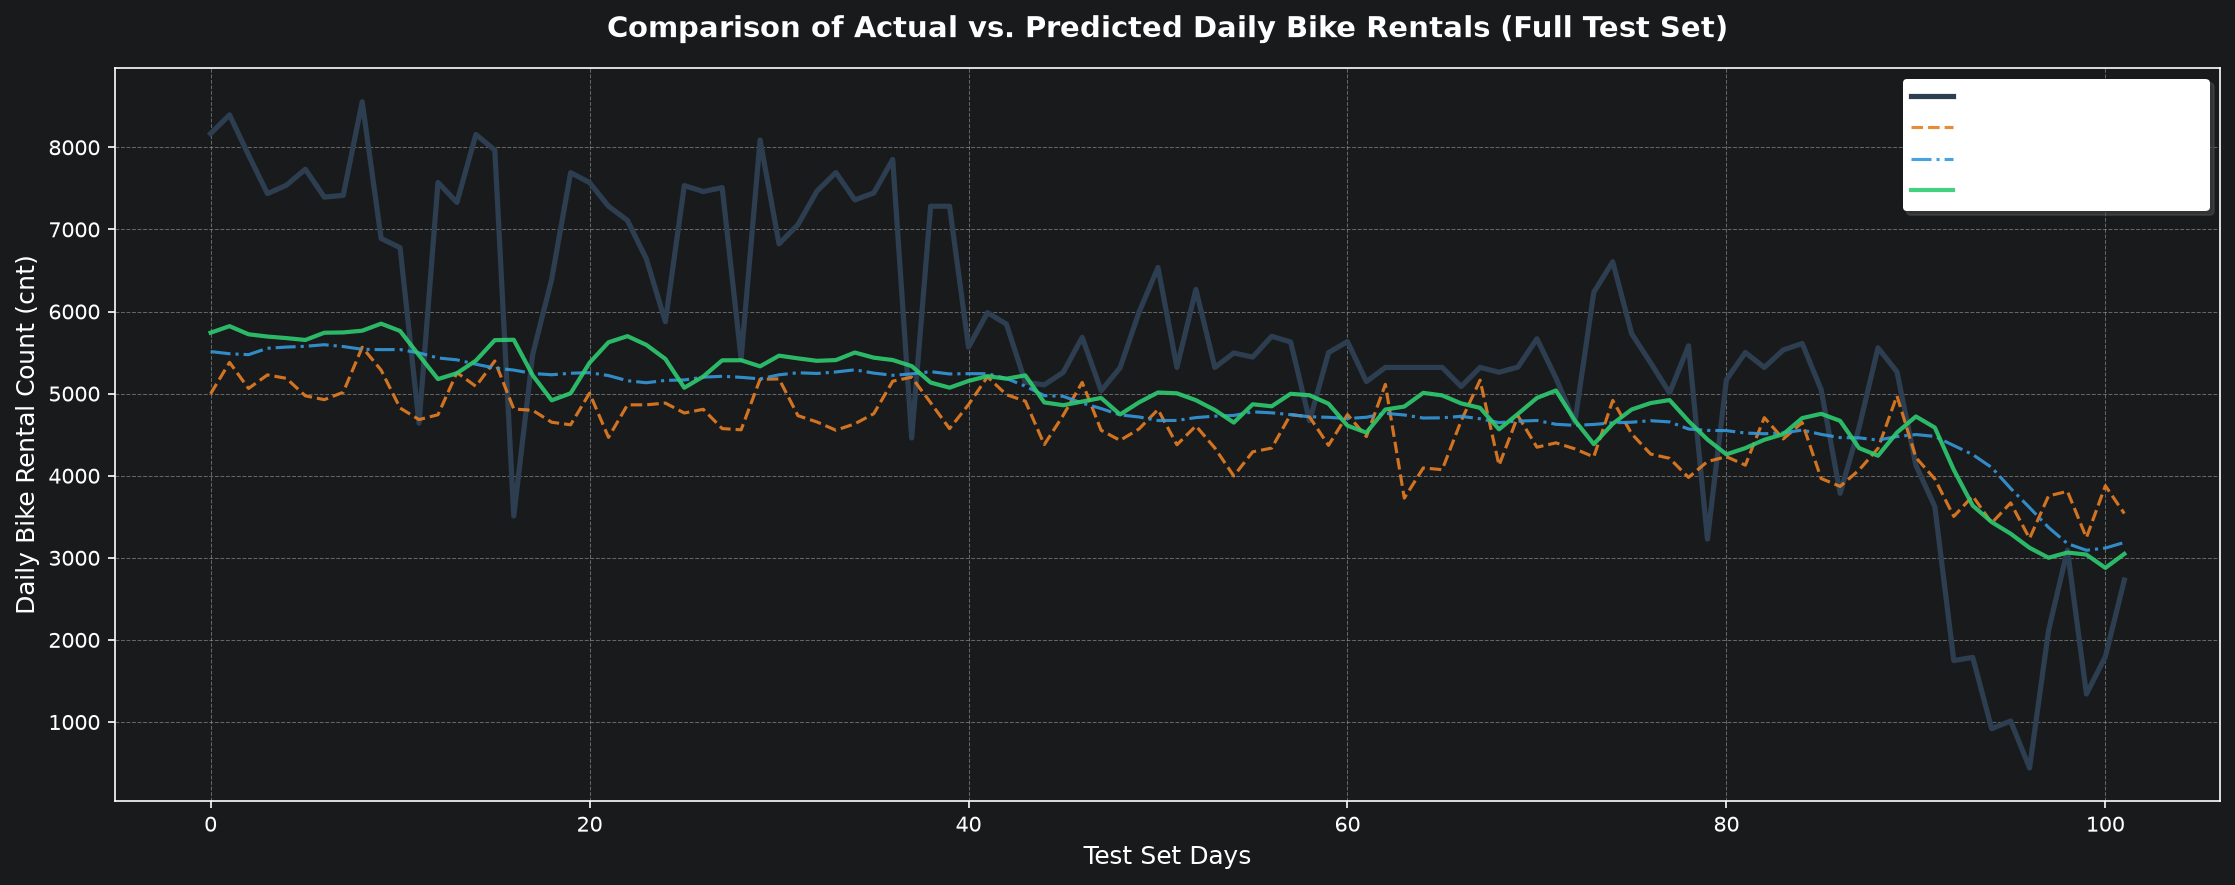

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6), dpi=150)
plt.plot(y_true, label="Actual Rentals", color="#2C3E50", linewidth=2.5, linestyle="-")
plt.plot(y_pred_rnn, label=f"SimpleRNN (R²: {rnn_metrics['R2']:.2f})", color="#E67E22", linewidth=1.5, linestyle="--", alpha=0.9)
plt.plot(y_pred_lstm, label=f"LSTM (R²: {lstm_metrics['R2']:.2f})", color="#3498DB", linewidth=1.5, linestyle="-.", alpha=0.9)
plt.plot(y_pred_gru, label=f"GRU (R²: {gru_metrics['R2']:.2f})", color="#2ECC71", linewidth=2.0, linestyle="-", alpha=0.9)

plt.title("Comparison of Actual vs. Predicted Daily Bike Rentals (Full Test Set)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Test Set Days", fontsize=12)
plt.ylabel("Daily Bike Rental Count (cnt)", fontsize=12)
plt.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none", shadow=True, fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("comparison_full_line_plot.png", dpi=300)
plt.show()

### 2. Zoomed-In Tracking (30-Day Window)

To better see the precise tracking and daily error dynamics, we zoom in on the **first 30 days** of the test set.

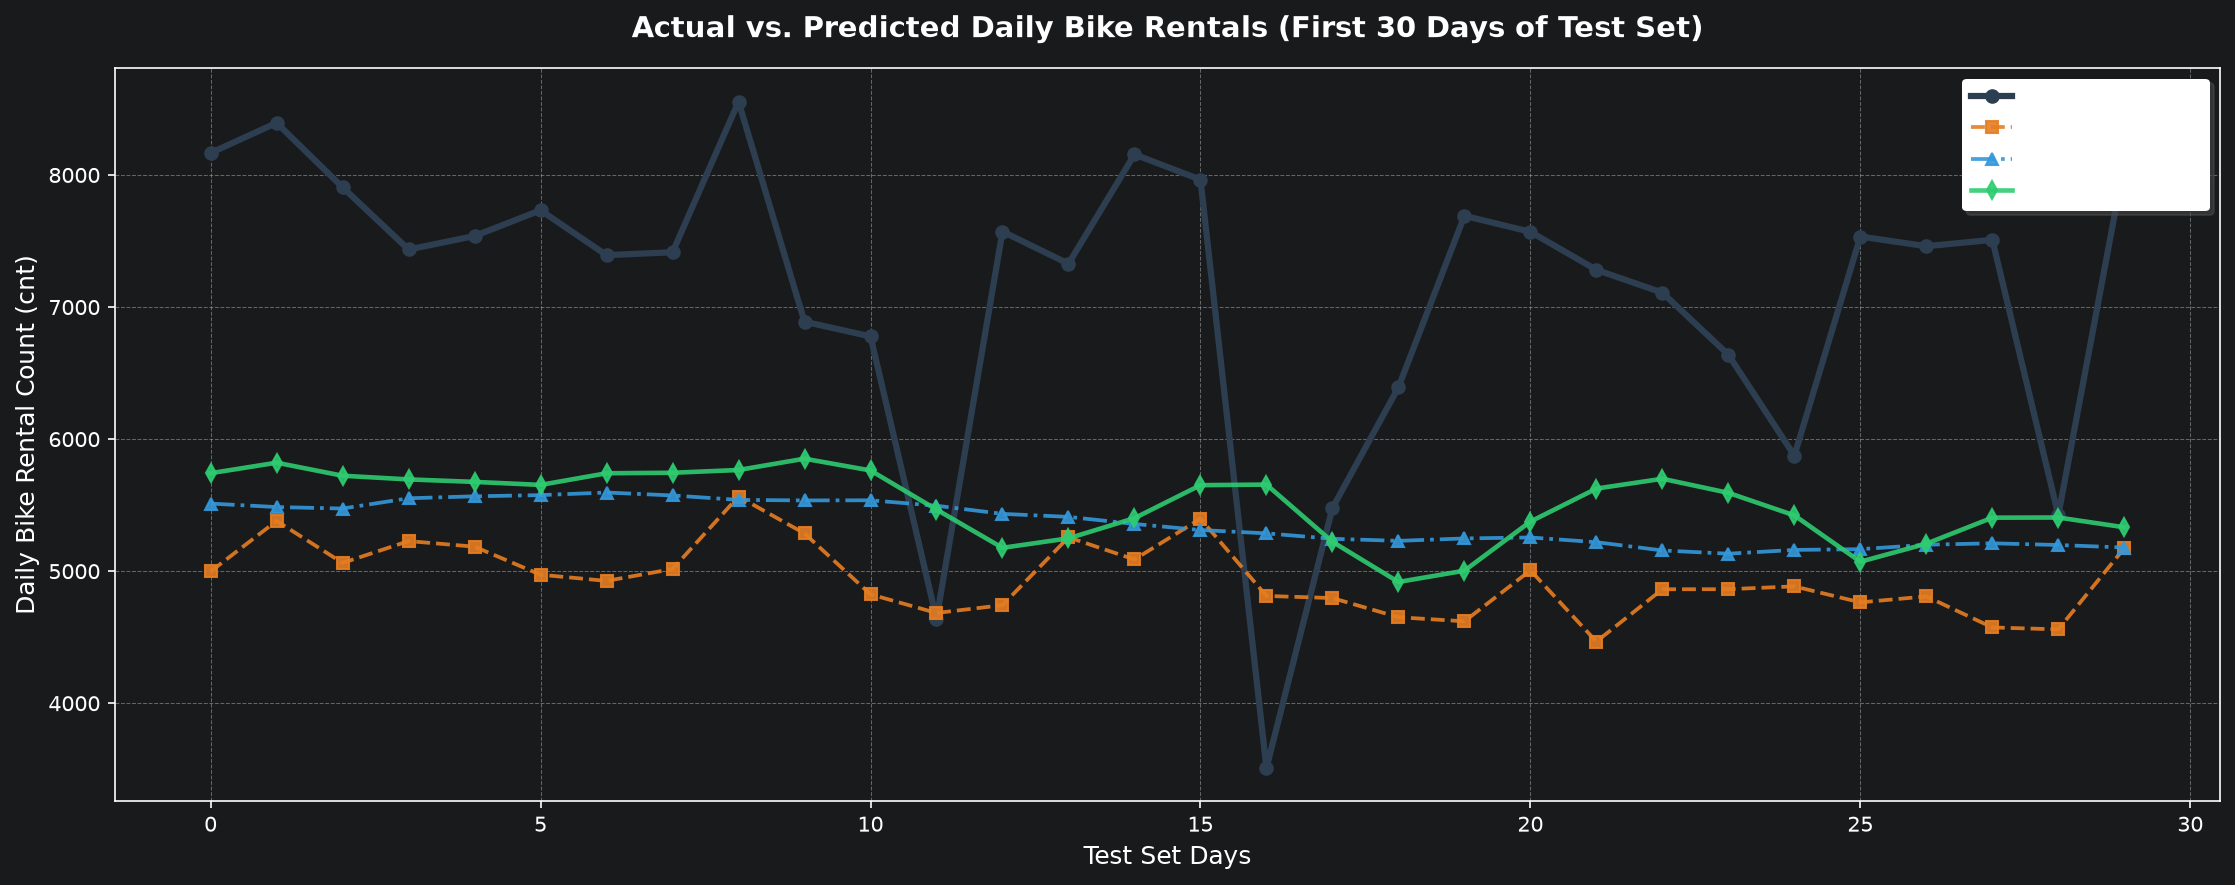

In [31]:
zoom_days = 30
plt.figure(figsize=(15, 6), dpi=150)
plt.plot(y_true[:zoom_days], label="Actual Rentals", color="#2C3E50", linewidth=3.0, marker="o")
plt.plot(y_pred_rnn[:zoom_days], label="SimpleRNN Pred", color="#E67E22", linewidth=1.8, linestyle="--", marker="s", alpha=0.9)
plt.plot(y_pred_lstm[:zoom_days], label="LSTM Pred", color="#3498DB", linewidth=1.8, linestyle="-.", marker="^", alpha=0.9)
plt.plot(y_pred_gru[:zoom_days], label="GRU Pred", color="#2ECC71", linewidth=2.2, linestyle="-", marker="d", alpha=0.9)

plt.title(f"Actual vs. Predicted Daily Bike Rentals (First {zoom_days} Days of Test Set)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Test Set Days", fontsize=12)
plt.ylabel("Daily Bike Rental Count (cnt)", fontsize=12)
plt.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none", shadow=True, fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("comparison_zoom_line_plot.png", dpi=300)
plt.show()

### 3. Scatter Plots with Line of Perfect Agreement

A scatter plot of actual vs. predicted values helps us evaluate model variance and systematic bias. The red dashed line represents the ideal scenario of perfect agreement ($y = x$).

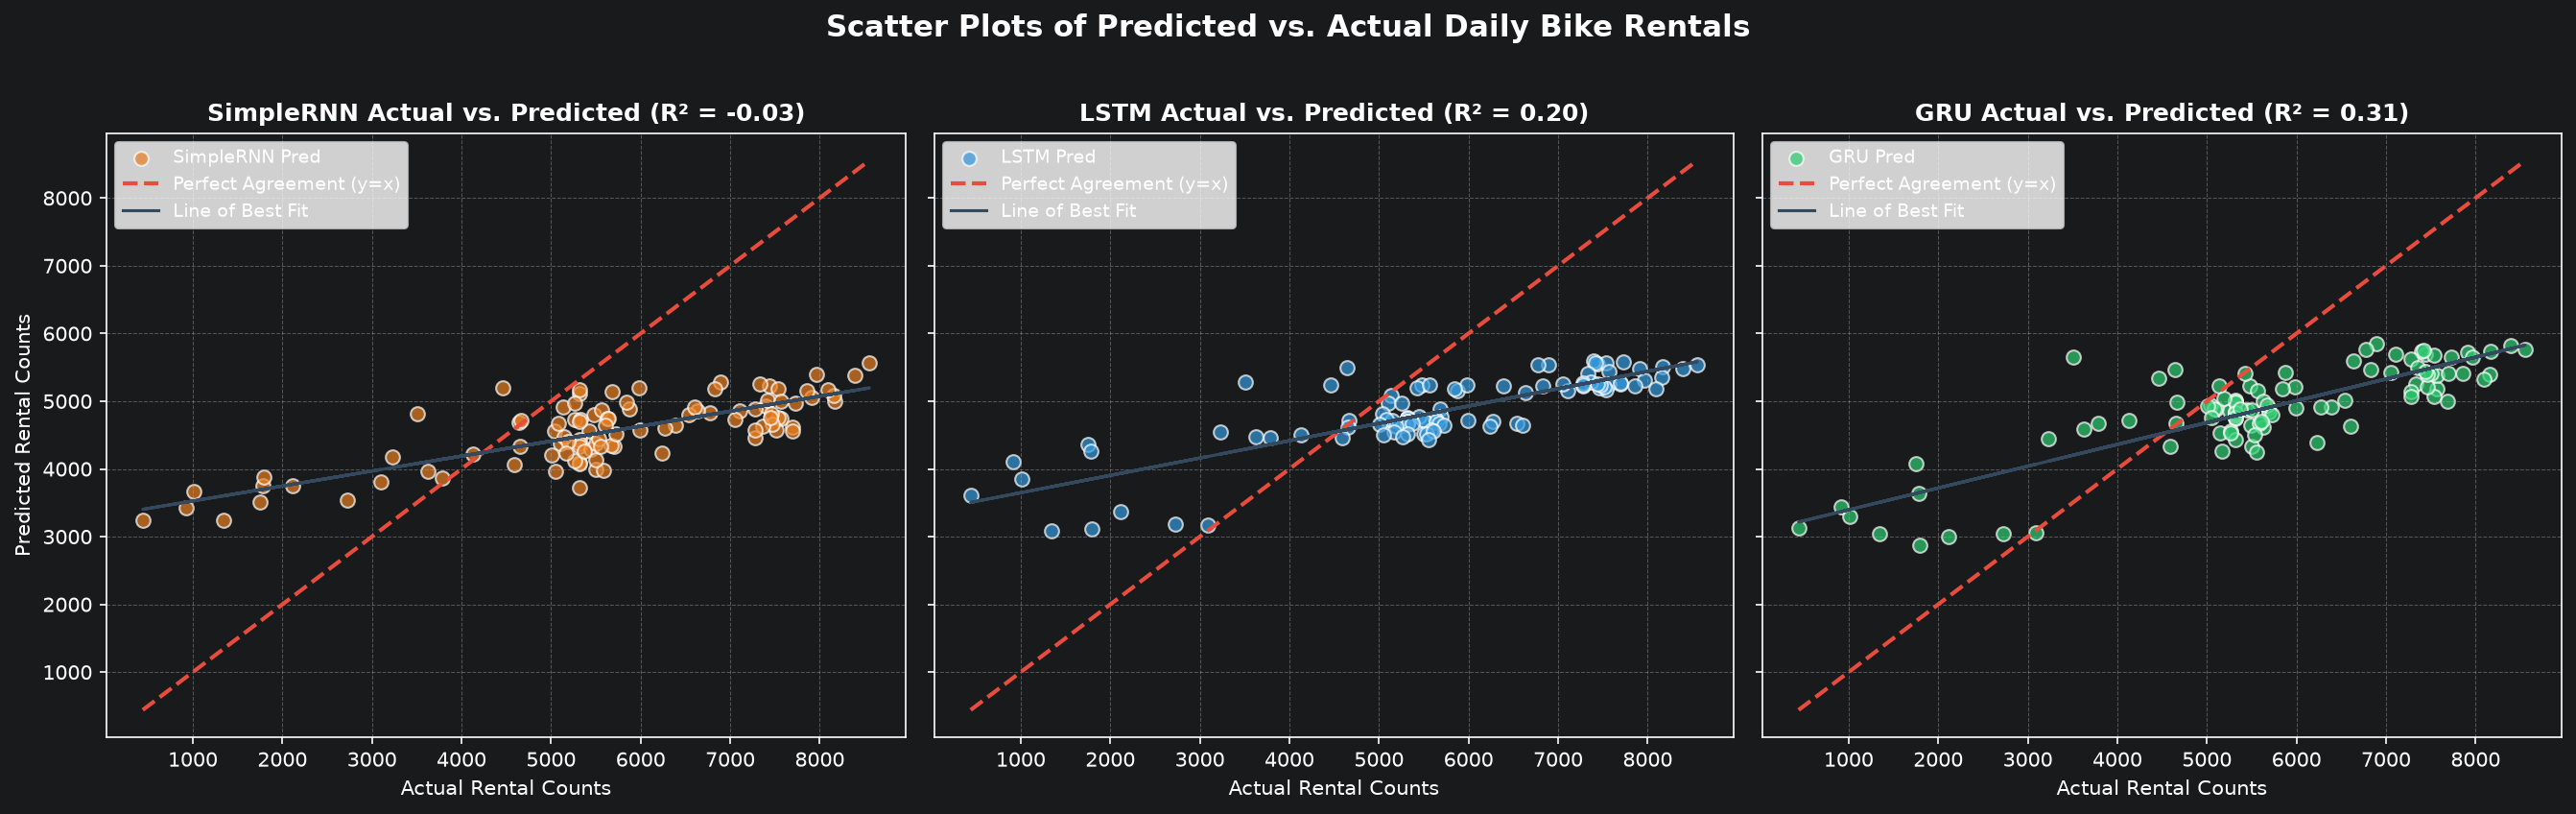

In [32]:
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True, dpi=150)
models_unscaled = [
    ("SimpleRNN", y_pred_rnn, "#E67E22", rnn_metrics['R2']),
    ("LSTM", y_pred_lstm, "#3498DB", lstm_metrics['R2']),
    ("GRU", y_pred_gru, "#2ECC71", gru_metrics['R2'])
]

min_val = min(y_true.min(), min(pred.min() for _, pred, _, _ in models_unscaled))
max_val = max(y_true.max(), max(pred.max() for _, pred, _, _ in models_unscaled))

for ax, (name, pred, color, r2) in zip(axes, models_unscaled):
    # Scatter plot
    ax.scatter(y_true, pred, alpha=0.7, color=color, edgecolors="w", s=50, label=f"{name} Pred")
    # y=x line
    ax.plot([min_val, max_val], [min_val, max_val], color="#E74C3C", linestyle="--", linewidth=2, label="Perfect Agreement (y=x)")
    
    # Fit line of the prediction
    m, b = np.polyfit(y_true, pred, 1)
    ax.plot(y_true, m*y_true + b, color="#34495E", linestyle="-", linewidth=1.5, label="Line of Best Fit")
    
    ax.set_title(f"{name} Actual vs. Predicted (R² = {r2:.2f})", fontsize=12, fontweight="bold")
    ax.set_xlabel("Actual Rental Counts", fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel("Predicted Rental Counts", fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(loc="upper left", fontsize=9, frameon=True, facecolor="white")

plt.suptitle("Scatter Plots of Predicted vs. Actual Daily Bike Rentals", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("comparison_scatter_plots.png", dpi=300, bbox_inches="tight")
plt.show()

### 4. Quantitative Performance Benchmarking

To compare the models quantitatively, we present a side-by-side bar chart comparison of their error metrics (RMSE and MAE) and R² coefficients.

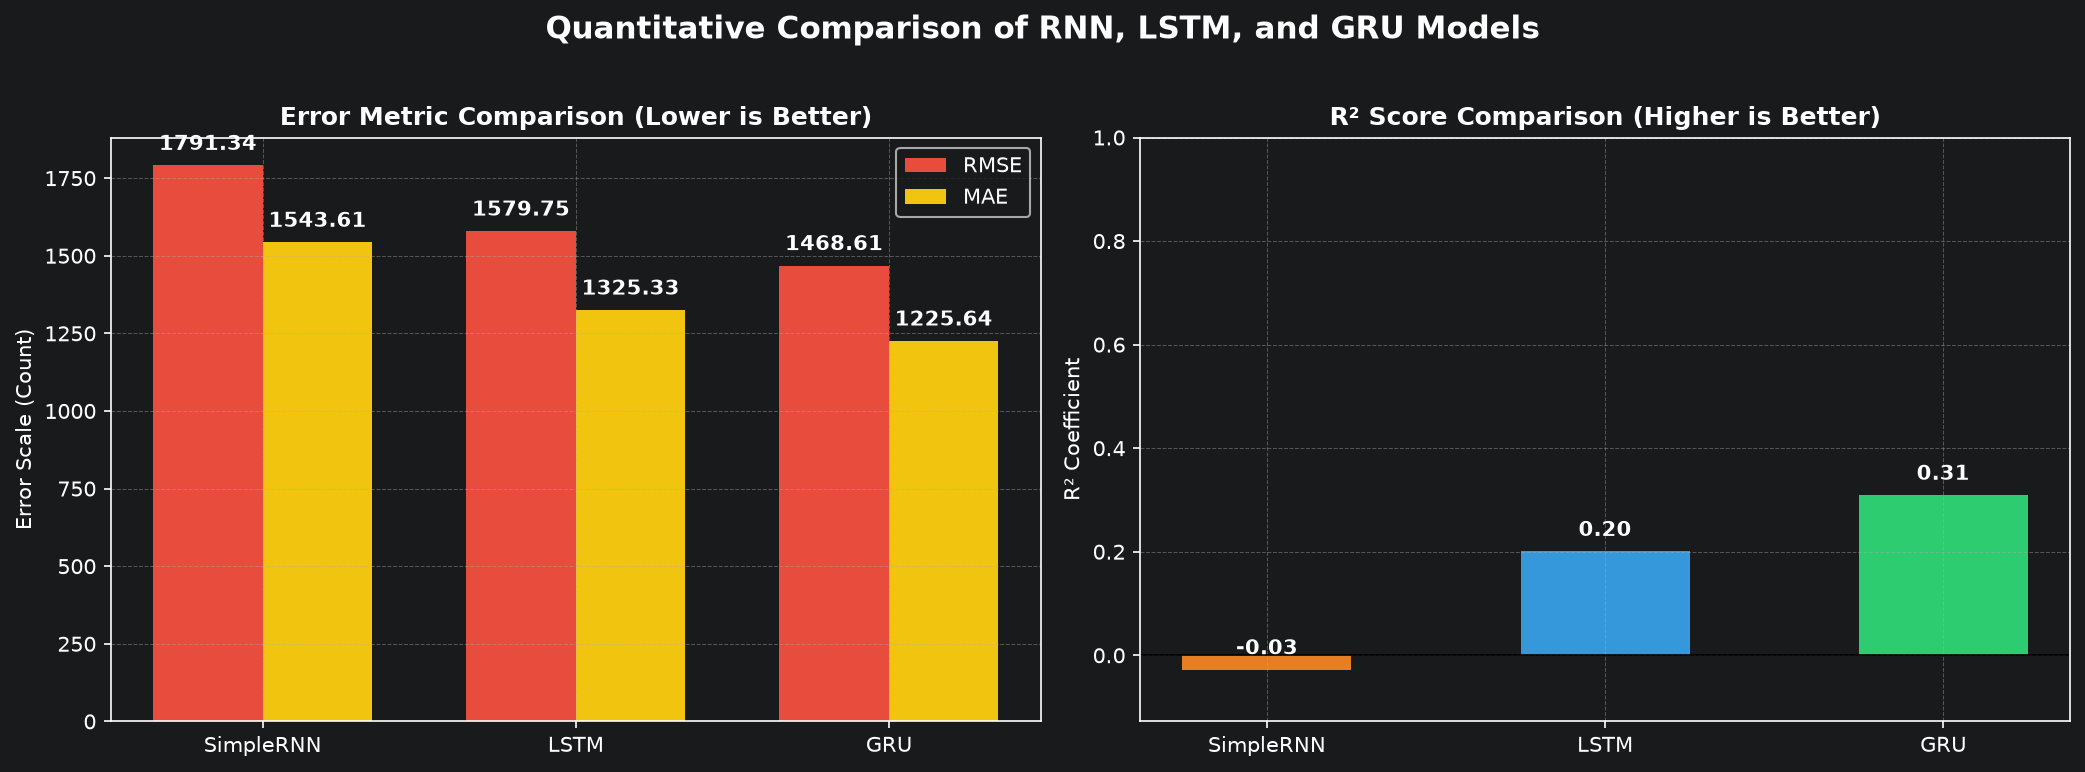

In [33]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Model": ["SimpleRNN", "LSTM", "GRU"],
    "RMSE": [rnn_metrics['RMSE'], lstm_metrics['RMSE'], gru_metrics['RMSE']],
    "MAE": [rnn_metrics['MAE'], lstm_metrics['MAE'], gru_metrics['MAE']],
    "R2": [rnn_metrics['R2'], lstm_metrics['R2'], gru_metrics['R2']]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# Error metrics bar chart
x = np.arange(len(metrics_df["Model"]))
width = 0.35
axes[0].bar(x - width/2, metrics_df["RMSE"], width, label="RMSE", color="#E74C3C")
axes[0].bar(x + width/2, metrics_df["MAE"], width, label="MAE", color="#F1C40F")
axes[0].set_title("Error Metric Comparison (Lower is Better)", fontsize=12, fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_df["Model"])
axes[0].set_ylabel("Error Scale (Count)", fontsize=10)
axes[0].legend(loc="upper right", frameon=True)
axes[0].grid(True, linestyle="--", alpha=0.4)

# R2 metrics bar chart
axes[1].bar(metrics_df["Model"], metrics_df["R2"], color=["#E67E22", "#3498DB", "#2ECC71"], width=0.5)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="-")
axes[1].set_title("R² Score Comparison (Higher is Better)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("R² Coefficient", fontsize=10)
axes[1].set_ylim(metrics_df["R2"].min() - 0.1, 1.0)
axes[1].grid(True, linestyle="--", alpha=0.4)

for ax in axes:
    for p in ax.patches:
        val = p.get_height()
        if abs(val) > 0.01: # Avoid labeling near-zero bars
            ax.annotate(f"{val:.2f}", (p.get_x() + p.get_width() / 2., val),
                        ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=10, fontweight="bold")

plt.suptitle("Quantitative Comparison of RNN, LSTM, and GRU Models", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("comparison_metrics_bar.png", dpi=300, bbox_inches="tight")
plt.show()